In [ ]:
###Evaluation 2
#Hier werden die Trainings mit wissenschaftlichen Metriken berechnet

In [1]:
import os

os.environ["HF_HOME"] = r"P:\hf-cache"
os.environ["TRANSFORMERS_CACHE"] = r"P:\hf-cache"
os.environ["TEMP"] = r"P:\temp"
os.environ["TMP"] = r"P:\temp"

In [ ]:
import re
import pandas as pd
import numpy as np
from tqdm import tqdm

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import emoji

In [ ]:
#DataFrame aus Datei lesen
df = pd.read_csv("eval_generations_100.csv")

required_cols = ["reference", "base_answer", "ft_answer"]
for col in required_cols:
    assert col in df.columns, f"Spalte fehlt: {col}"

df["reference"] = df["reference"].fillna("").astype(str)
df["base_answer"] = df["base_answer"].fillna("").astype(str)
df["ft_answer"] = df["ft_answer"].fillna("").astype(str)

print(df[["reference", "base_answer", "ft_answer"]].head())
print("Anzahl Beispiele:", len(df))

In [4]:
#vereinfachte "Tokenisierung" nach wörtern und Zeichen
def simple_tokenize(text):
 
    return re.findall(r"\w+|[^\w\s]", str(text), re.UNICODE)

#Smooth Funktion glättet Ergebnis falls ein Faktor x der BLEU n-Gramme  0 ergibt und Produkt 0 ergibt
smooth = SmoothingFunction().method1

#BLEU-4 Score berechnen mit gleicher Gewichtung von 1,2,3,4-Grammen
def calculate_bleu(reference, candidate):
    ref_tokens = simple_tokenize(reference)
    cand_tokens = simple_tokenize(candidate)

    if len(ref_tokens) == 0 or len(cand_tokens) == 0:
        return 0.0

    return sentence_bleu(
        [ref_tokens],
        cand_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

#Nur exakte Wörter zählen, kein Wortstamm
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

#Rouge berechnen, 0 falls leer
def calculate_rouge_l(reference, candidate):
    if not reference.strip() or not candidate.strip():
        return 0.0

    scores = rouge.score(reference, candidate)
    return scores["rougeL"].fmeasure

#Emojis zählen
def count_emojis(text):
    return emoji.emoji_count(str(text))

#Länge der chars
def text_length_chars(text):
    return len(str(text))

#Tokenanzahl
def text_length_tokens(text):
    return len(simple_tokenize(text))

#emoji Verhältnis
def emoji_density(text):
    tokens = simple_tokenize(text)
    if len(tokens) == 0:
        return 0.0
    return count_emojis(text) / len(tokens)

#Nicht leere Zeilen zählen
def count_non_empty_lines(text):

    text = str(text)
    lines = text.splitlines()
    non_empty_lines = [line for line in lines if line.strip()]
    return len(non_empty_lines)

In [5]:
#BLEU und ROUGE-L berechnen
metrics = df.copy()

#BLEU
metrics["bleu_base"] = [
    calculate_bleu(ref, cand)
    for ref, cand in tqdm(zip(metrics["reference"], metrics["base_answer"]), total=len(metrics), desc="BLEU Base")
]

metrics["bleu_ft"] = [
    calculate_bleu(ref, cand)
    for ref, cand in tqdm(zip(metrics["reference"], metrics["ft_answer"]), total=len(metrics), desc="BLEU FT")
]

#ROUGE-L
metrics["rougeL_base"] = [
    calculate_rouge_l(ref, cand)
    for ref, cand in tqdm(zip(metrics["reference"], metrics["base_answer"]), total=len(metrics), desc="ROUGE-L Base")
]

metrics["rougeL_ft"] = [
    calculate_rouge_l(ref, cand)
    for ref, cand in tqdm(zip(metrics["reference"], metrics["ft_answer"]), total=len(metrics), desc="ROUGE-L FT")
]

#Antwortlängen vergleichen
metrics["len_reference_chars"] = metrics["reference"].apply(text_length_chars)
metrics["len_base_chars"] = metrics["base_answer"].apply(text_length_chars)
metrics["len_ft_chars"] = metrics["ft_answer"].apply(text_length_chars)

metrics["len_reference_tokens"] = metrics["reference"].apply(text_length_tokens)
metrics["len_base_tokens"] = metrics["base_answer"].apply(text_length_tokens)
metrics["len_ft_tokens"] = metrics["ft_answer"].apply(text_length_tokens)

#Emojis vergleichen
metrics["emoji_reference"] = metrics["reference"].apply(count_emojis)
metrics["emoji_base"] = metrics["base_answer"].apply(count_emojis)
metrics["emoji_ft"] = metrics["ft_answer"].apply(count_emojis)

metrics["emoji_density_reference"] = metrics["reference"].apply(emoji_density)
metrics["emoji_density_base"] = metrics["base_answer"].apply(emoji_density)
metrics["emoji_density_ft"] = metrics["ft_answer"].apply(emoji_density)

ROUGE-L FT: 100%|██████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 8338.41it/s]


In [6]:
#BERTScore berechnen

bert_model = "bert-base-multilingual-cased"

#Base vs Reference
P_base, R_base, F1_base = bert_score(
    cands=metrics["base_answer"].tolist(),
    refs=metrics["reference"].tolist(),
    model_type=bert_model,
    lang="de",
    verbose=True,
    rescale_with_baseline=False
)

#Fine-Tuned vs Reference
P_ft, R_ft, F1_ft = bert_score(
    cands=metrics["ft_answer"].tolist(),
    refs=metrics["reference"].tolist(),
    model_type=bert_model,
    lang="de",
    verbose=True, #Ladebalken
    rescale_with_baseline=False #Skalierung strecken
)

metrics["bertscore_precision_base"] = P_base.cpu().numpy() #Tensoren mit CPU in Zahlen umwandeln
metrics["bertscore_recall_base"] = R_base.cpu().numpy()
metrics["bertscore_f1_base"] = F1_base.cpu().numpy()

metrics["bertscore_precision_ft"] = P_ft.cpu().numpy()
metrics["bertscore_recall_ft"] = R_ft.cpu().numpy()
metrics["bertscore_f1_ft"] = F1_ft.cpu().numpy()

calculating scores...
computing bert embedding.


  0%|          | 0/3 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 1.35 seconds, 73.84 sentences/sec
calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 0.50 seconds, 198.03 sentences/sec


In [7]:
#Veränderung messen
metrics["delta_bertscore_f1"] = metrics["bertscore_f1_ft"] - metrics["bertscore_f1_base"]
metrics["delta_bleu"] = metrics["bleu_ft"] - metrics["bleu_base"]
metrics["delta_rougeL"] = metrics["rougeL_ft"] - metrics["rougeL_base"]

#Absolute Abweichung
metrics["abs_len_diff_base"] = (metrics["len_base_tokens"] - metrics["len_reference_tokens"]).abs()
metrics["abs_len_diff_ft"] = (metrics["len_ft_tokens"] - metrics["len_reference_tokens"]).abs()

metrics["abs_emoji_diff_base"] = (metrics["emoji_base"] - metrics["emoji_reference"]).abs()
metrics["abs_emoji_diff_ft"] = (metrics["emoji_ft"] - metrics["emoji_reference"]).abs()

In [8]:
#Zusammenfassung aller Werte

summary = {
    "BERTScore F1 Base": metrics["bertscore_f1_base"].mean(),
    "BERTScore F1 FT": metrics["bertscore_f1_ft"].mean(),
    "BLEU Base": metrics["bleu_base"].mean(),
    "BLEU FT": metrics["bleu_ft"].mean(),
    "ROUGE-L Base": metrics["rougeL_base"].mean(),
    "ROUGE-L FT": metrics["rougeL_ft"].mean(),
    "Ø Länge Reference Tokens": metrics["len_reference_tokens"].mean(),
    "Ø Länge Base Tokens": metrics["len_base_tokens"].mean(),
    "Ø Länge FT Tokens": metrics["len_ft_tokens"].mean(),
    "Ø Emoji Reference": metrics["emoji_reference"].mean(),
    "Ø Emoji Base": metrics["emoji_base"].mean(),
    "Ø Emoji FT": metrics["emoji_ft"].mean(),
}

summary_df = pd.DataFrame(summary.items(), columns=["Metrik", "Wert"])
summary_df

,Metrik,Wert
0,BERTScore F1 Base,0.542849
1,BERTScore F1 FT,0.634173
2,BLEU Base,0.001769
3,BLEU FT,0.007298
4,ROUGE-L Base,0.022862
5,ROUGE-L FT,0.052191
6,Ø Länge Reference Tokens,14.520000
7,Ø Länge Base Tokens,55.330000
8,Ø Länge FT Tokens,18.690000
9,Ø Emoji Reference,1.290000


In [9]:
#Automatische Metriken Übersicht
print("Durchschnittliche Verbesserungen:")
print("Δ BERTScore F1:", metrics["delta_bertscore_f1"].mean())
print("Δ BLEU:", metrics["delta_bleu"].mean())
print("Δ ROUGE-L:", metrics["delta_rougeL"].mean())

print("FT besser als Base Häufigkeit")
print("BERTScore:", (metrics["delta_bertscore_f1"] > 0).mean())
print("BLEU:", (metrics["delta_bleu"] > 0).mean())
print("ROUGE-L:", (metrics["delta_rougeL"] > 0).mean())

Durchschnittliche Verbesserungen:
Δ BERTScore F1: 0.09132416
Δ BLEU: 0.005528266772981776
Δ ROUGE-L: 0.0293286386561303
FT besser als Base Häufigkeit
BERTScore: 0.91
BLEU: 0.5
ROUGE-L: 0.33


In [10]:
#Speichern
metrics.to_csv("eval_metrics_100_2.csv", index=False, encoding="utf-8-sig")

summary_df.to_csv("eval_metrics_summary_2.csv", index=False, encoding="utf-8-sig")

In [11]:
## Trainingsgrafiken generieren

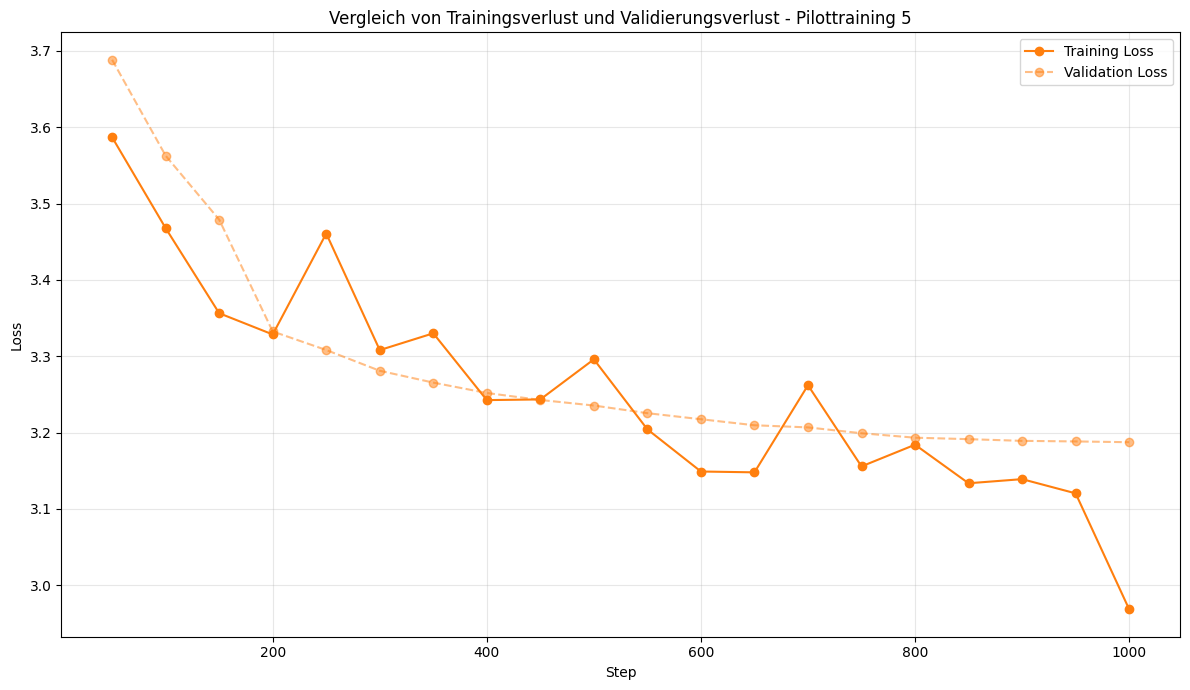

In [12]:
import matplotlib.pyplot as plt

# Daten
steps = [
    50, 100, 150, 200, 250, 300, 350, 400, 450, 500,
    550, 600, 650, 700, 750, 800, 850, 900, 950, 1000
]

training_loss = [
3.586800,
3.467800,
3.356400,
3.328600,
3.460800,
3.308100,
3.330100,
3.242600,
3.243500,
3.296000,
3.204300,
3.149100,
3.148000,
3.262100,
3.155800,
3.184200,
3.133700,
3.139100,
3.120500,
2.968700
]


validation_loss = [
3.688285,
3.562678,
3.478948,
3.332526,
3.308190,
3.281023,
3.265524,
3.251920,
3.242793,
3.235503,
3.225494,
3.217554,
3.209671,
3.206857,
3.199191,
3.193377,
3.191465,
3.189236,
3.188483,
3.187474
]


plt.figure(figsize=(12, 7))
plt.plot(steps, training_loss, marker='o',color="C1", label='Training Loss')
plt.plot(steps, validation_loss, marker='o',color="C1",
    alpha=0.5, linestyle='--', label='Validation Loss')

plt.title('Vergleich von Trainingsverlust und Validierungsverlust - Pilottraining 5')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


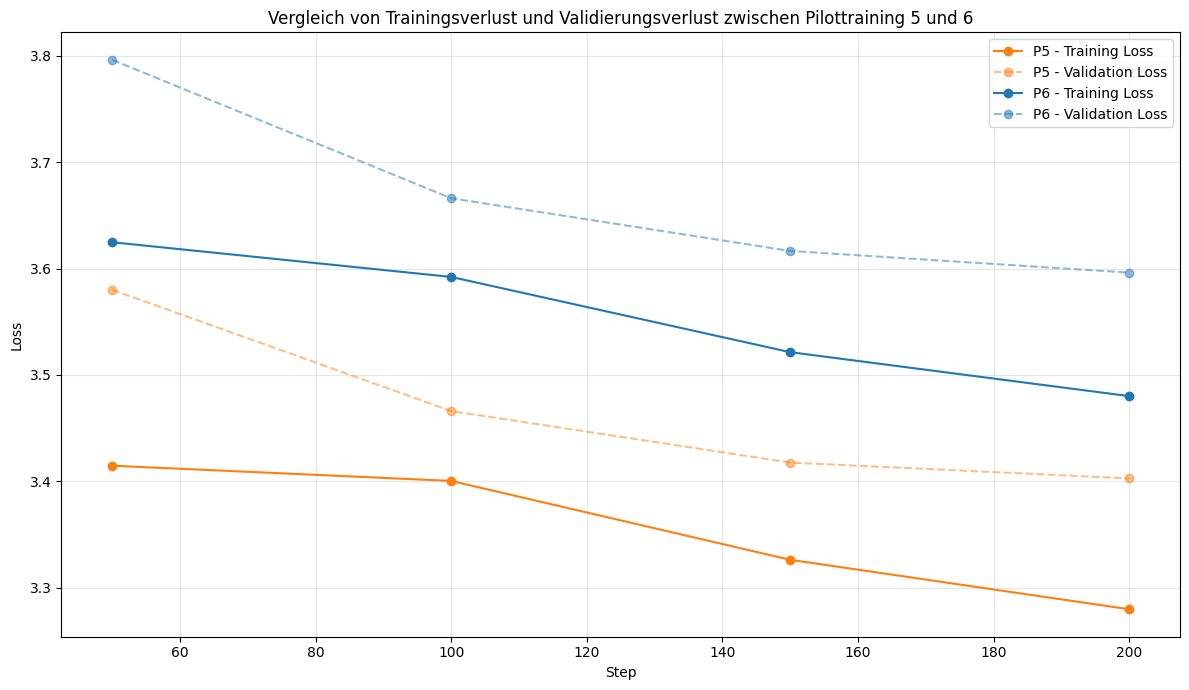

In [13]:
import matplotlib.pyplot as plt

# Steps
steps = [
50,
100,
150,
200
]


# Training 1
training1_loss = [
3.414700,
3.400400,
3.326300,
3.279800
]




validation1_loss = [
3.580005,
3.466090,
3.417667,
3.402743
]


# Training 2
training2_loss = [
3.624700,
3.592100,
3.521400,
3.480100
]


validation2_loss = [
3.796142,
3.666054,
3.616532,
3.596138
]

plt.figure(figsize=(12, 7))

plt.plot(
    steps,
    training1_loss,
    marker="o",
    color="C1",
    label="P5 - Training Loss"
)

plt.plot(
    steps,
    validation1_loss,
    marker="o",
    color="C1",
    alpha=0.5,
    linestyle="--",
    label="P5 - Validation Loss"
)

plt.plot(
    steps,
    training2_loss,
    marker="o",
    color="C0",
    label='P6 - Training Loss'
)

plt.plot(
    steps,
    validation2_loss,
    marker="o",
    color="C0",
    alpha=0.5,
    linestyle='--',
    label="P6 - Validation Loss"
)

plt.title("Vergleich von Trainingsverlust und Validierungsverlust zwischen Pilottraining 5 und 6")
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


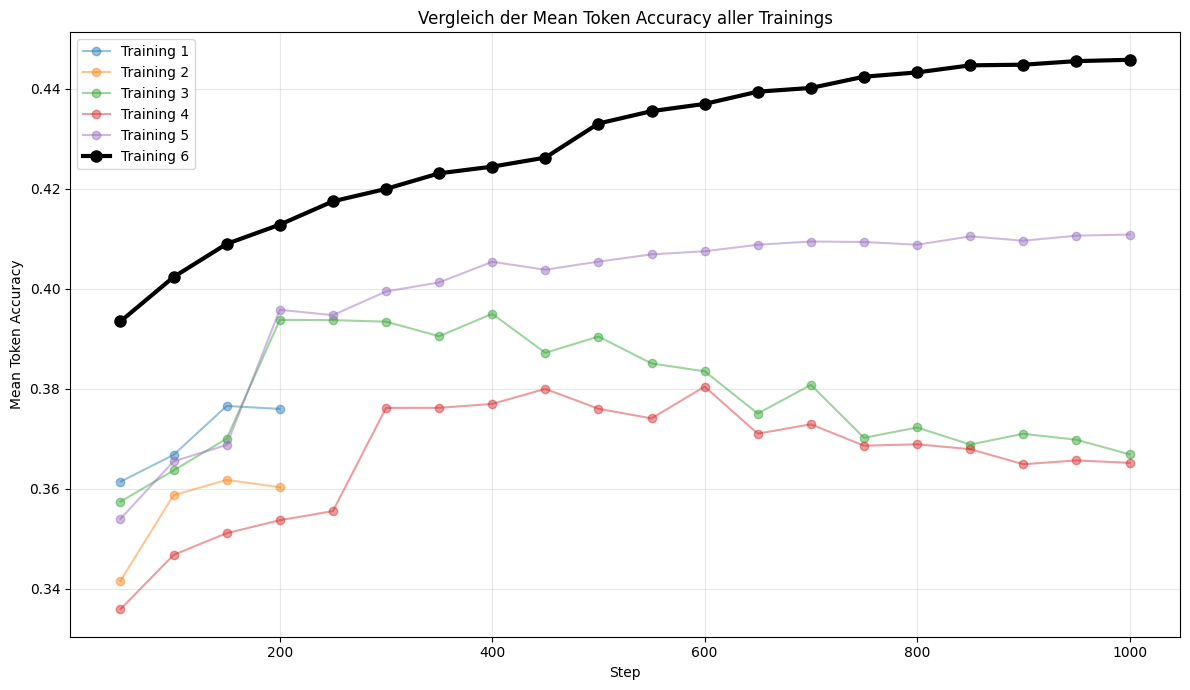

In [14]:
import matplotlib.pyplot as plt


steps_200 = [50, 100, 150, 200]

steps_1000 = [
    50, 100, 150, 200, 250, 300, 350, 400, 450, 500,
    550, 600, 650, 700, 750, 800, 850, 900, 950, 1000
]


accuracy1 = [
    0.361382,
    0.366743,
    0.376526,
    0.375944
]


accuracy2 = [
    0.341556,
    0.358676,
    0.361734,
    0.360280
]


accuracy3 = [
    0.357390,
    0.363629,
    0.369990,
    0.393755,
    0.393701,
    0.393397,
    0.390481,
    0.394963,
    0.387151,
    0.390422,
    0.385031,
    0.383462,
    0.375010,
    0.380756,
    0.370161,
    0.372221,
    0.368806,
    0.370965,
    0.369767,
    0.366855
]


accuracy4 = [
    0.335856,
    0.346731,
    0.351077,
    0.353668,
    0.355492,
    0.376129,
    0.376156,
    0.376937,
    0.379941,
    0.375974,
    0.374044,
    0.380397,
    0.370988,
    0.372860,
    0.368582,
    0.368858,
    0.367881,
    0.364866,
    0.365639,
    0.365145
]


accuracy5 = [
    0.353943,
    0.365450,
    0.368738,
    0.395763,
    0.394698,
    0.399440,
    0.401248,
    0.405375,
    0.403785,
    0.405405,
    0.406861,
    0.407487,
    0.408779,
    0.409431,
    0.409338,
    0.408784,
    0.410463,
    0.409591,
    0.410601,
    0.410827
]


accuracy6 = [
    0.393450,
    0.402328,
    0.408958,
    0.412810,
    0.417475,
    0.419959,
    0.423076,
    0.424413,
    0.426219,
    0.433038,
    0.435512,
    0.436961,
    0.439413,
    0.440156,
    0.442404,
    0.443265,
    0.444680,
    0.444807,
    0.445525,
    0.445787
]

plt.figure(figsize=(12, 7))


plt.plot(
    steps_200,
    accuracy1,
    marker="o",
    alpha=0.45,
    label="Training 1"
)

plt.plot(
    steps_200,
    accuracy2,
    marker="o",
    alpha=0.45,
    label="Training 2"
)

plt.plot(
    steps_1000,
    accuracy3,
    marker="o",
    alpha=0.45,
    label="Training 3"
)

plt.plot(
    steps_1000,
    accuracy4,
    marker="o",
    alpha=0.45,
    label="Training 4"
)

plt.plot(
    steps_1000,
    accuracy5,
    marker="o",
    alpha=0.45,
    label="Training 5"
)


plt.plot(
    steps_1000,
    accuracy6,
    marker="o",
    markersize=8,
    linewidth=3,
    color="black",
    label="Training 6"
)

plt.title("Vergleich der Mean Token Accuracy aller Trainings")
plt.xlabel("Step")
plt.ylabel("Mean Token Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()
